In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import os



In [3]:
import pandas as pd


# sipin_path = r"C:\Users\maryl\Documents\Universite\Session_6\tp_biom\exam_lab\Si-PIN_60.30x_Am241_60s_1024.mca"
folder = r"C:\Users\charl\OneDrive\UL\Travaux pratiques PhysMed\Filtration X\TPmedical\spectres_bruts\mesures_supp"

files = os.listdir(folder)

for file in files:
    print(file[:-4])

    path = rf"{folder}\{file}"
    with open(path, "r") as f:
        lines = f.readlines()

    # Exemple : garder seulement les lignes numériques
    data = []
    for line in lines:
        try:
            value = float(line.strip())
            data.append(value)
        except:
            pass


    df = pd.DataFrame(data, columns=["Counts"])
    df.to_csv(rf"C:\Users\charl\OneDrive\UL\Travaux pratiques PhysMed\Filtration X\TPmedical\spectres_bruts\supp_csv\{file[:-4]}.csv", index=False)

Ag_1mils
Al_10mils
Al_20mils
Al_30mils
Al_40mils
Al_50mils
Al_60mils
Al_70mils
Al_80mils
Al_80mils_passur
Cu_1mils
Cu_1mils_V2
Cu_2mils
Cu_3mils
Cu_4mils
Cu_5mils
Mo_1mils
sansfiltre
W_1mils


[ 0.  0.  0. ... 16. 27. 32.]


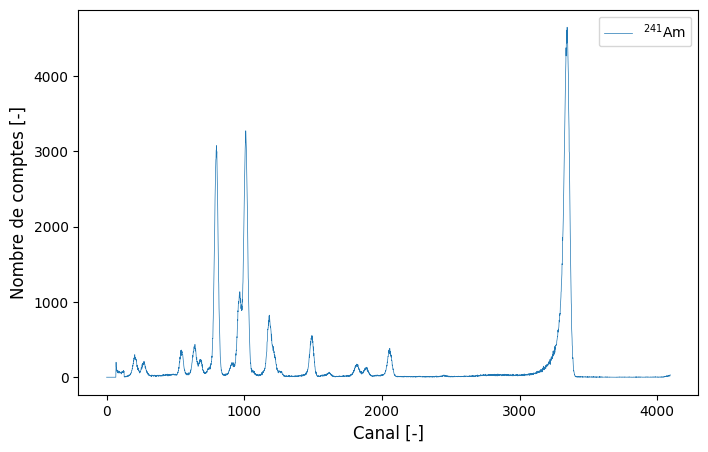

In [4]:
df = pd.read_csv('csv\Am241_76.70X_4096_etalonnage1.csv')
Am241 = df.to_numpy().ravel()
print(Am241)


fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Am241, lw=0.5, label=r"$^{241}$Am")
ax.legend()
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes [-]", size=12)
plt.show()

[ 796  798 1009 1011 3338 3343 3346 3348]


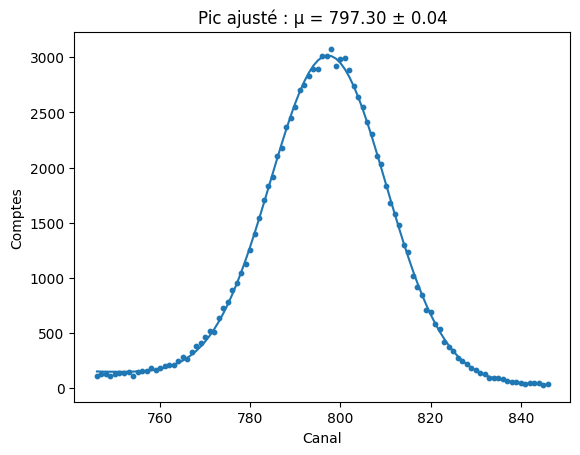

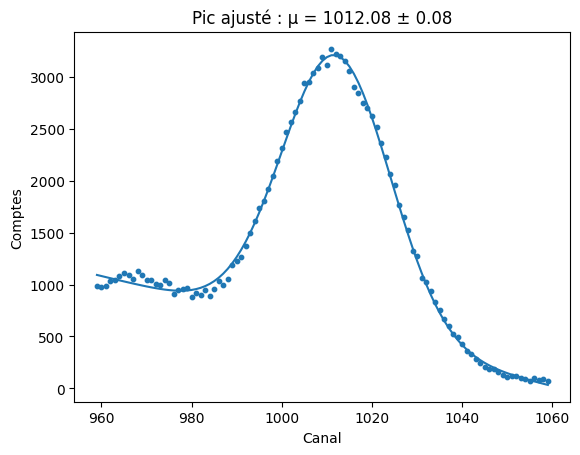

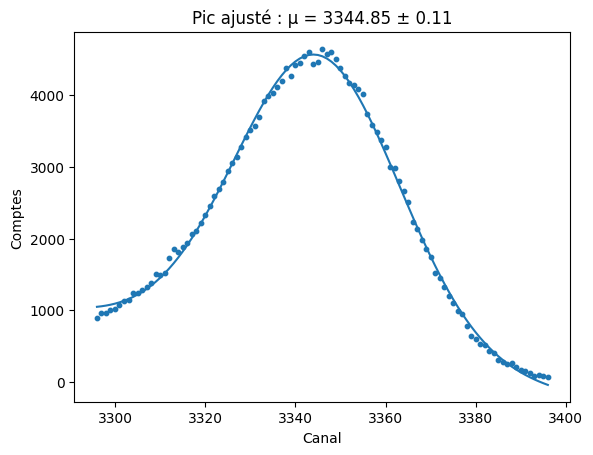

In [5]:
# Modèle gaussienne + fond linéaire
def gaussian_with_background(x, A, mu, sigma, m, c):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2)) + m*x + c


def fit_peak(counts, peak_center, window=30, plot=True):
    """
    counts : array numpy des comptes
    peak_center : estimation approximative du pic
    window : nombre de canaux autour du pic
    """

    # Définition de la région de fit
    x_min = peak_center - window
    x_max = peak_center + window
    
    x = np.arange(len(counts))
    mask = (x >= x_min) & (x <= x_max)

    x_fit = x[mask]
    y_fit = counts[mask]

    # Valeurs initiales
    A0 = max(y_fit)
    mu0 = peak_center
    sigma0 = window/3
    m0 = 0
    c0 = min(y_fit)

    p0 = [A0, mu0, sigma0, m0, c0]

    # Fit
    popt, pcov = curve_fit(gaussian_with_background, x_fit, y_fit, p0=p0)

    A, mu, sigma, m, c = popt
    mu_err = np.sqrt(np.diag(pcov))[1]
    sigma_err = np.sqrt(np.diag(pcov))[2]

    # Nombre de compte dans le pic
    N_pic = A*sigma*np.sqrt(2*np.pi)


    if plot:
        plt.figure()
        plt.scatter(x_fit, y_fit, s=10)
        plt.plot(x_fit, gaussian_with_background(x_fit, *popt))
        plt.title(f"Pic ajusté : μ = {mu:.2f} ± {mu_err:.2f}")
        plt.xlabel("Canal")
        plt.ylabel("Comptes")
        plt.show()

    return mu, mu_err, sigma, sigma_err, N_pic


peaks, _ = find_peaks(Am241, height=3000)  # ajuster height
print(peaks)

mu_Am1, mu_err_Am1, sigma_Am1, sigma_err_Am1, _ = fit_peak(Am241, peak_center=796, window=50)

mu_Am2, mu_err_CAm2, sigma_Am2, sigma_err_Am2, _ = fit_peak(Am241, peak_center=1009, window=50)

mu_Am3, mu_err_Am3, sigma_Am3, sigma_err_Am3, _ = fit_peak(Am241, peak_center=3346, window=50)


# Étalonnage

Gain (keV/canal) = 0.017905141963904726
Offset (keV) = -0.35239275479242


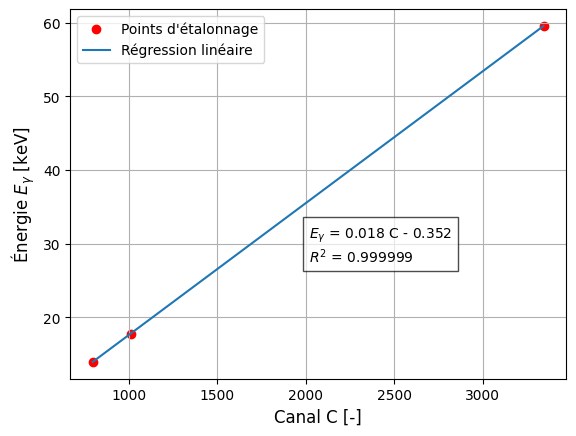

In [6]:
# Étalonnage

channels = np.array([mu_Am1, mu_Am2, mu_Am3])
energies = np.array([13.95, 17.74, 59.54])


coeff = np.polyfit(channels, energies, 1)

a = coeff[0]
b = coeff[1]

print("Gain (keV/canal) =", a)
print("Offset (keV) =", b)  


def etalon(channel):
    return a * channel + b

# Calcul de R^2
ss_res = np.sum((energies - etalon(channels))**2)
ss_tot = np.sum((energies - np.mean(energies))**2)
r2 = 1 - ss_res/ss_tot


plt.scatter(channels, energies, label="Points d'étalonnage", color='red')
plt.plot(channels, etalon(channels), label="Régression linéaire")


# Calcul du point milieu
x_mid = np.mean(channels)
y_mid = a * x_mid + b

# Affichage équation sur le graphe
plt.text(x_mid+300,
         y_mid-3,
         r"$E_\gamma$"+f" = {a:.3f} C - {np.abs(b):.3f}\n$R^2$ = {r2:.6f}",
         fontsize=10,
         bbox=dict(facecolor='white', alpha=0.7))

plt.xlabel("Canal C [-]", size=12)
plt.ylabel(r"Énergie $E_\gamma$ [keV]", size=12)
plt.legend(loc="best")
plt.grid()


plt.show()

# Filtres 

In [7]:
df = pd.read_csv(r'spectres_bruts\supp_csv\Ag_1mils.csv')
Ag_1mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Al_10mils.csv')
Al_10mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Cu_1mils.csv')
Cu_1mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Mo_1mils.csv')
Mo_1mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\W_1mils.csv')
W_1mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\sansfiltre.csv')
no_filter = df.to_numpy().ravel()


[ 5.  8. 11. ...  8.  8.  6.]
3968
[26.322329215727752, 26.590880787903167, 26.660602531939887, 26.628695958039852, 25.33058225895014, 28.033727907587686]
[2031522.0, 1969943.0, 1818106.0, 1160393.0, 1325468.0, 824871.0]

 [0.01476558 0.6164813 ] [1.45914652e-02 2.60959280e+01]
RMSE (énergies moyennes) = 0.7086280664551778 keV
RMSE (énergies maximales) = 0.29086289406131327 keV


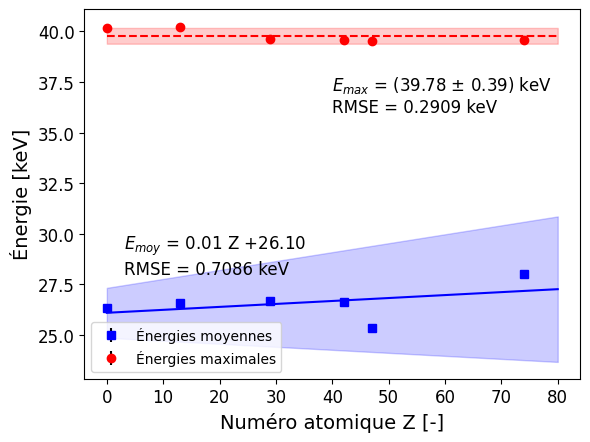

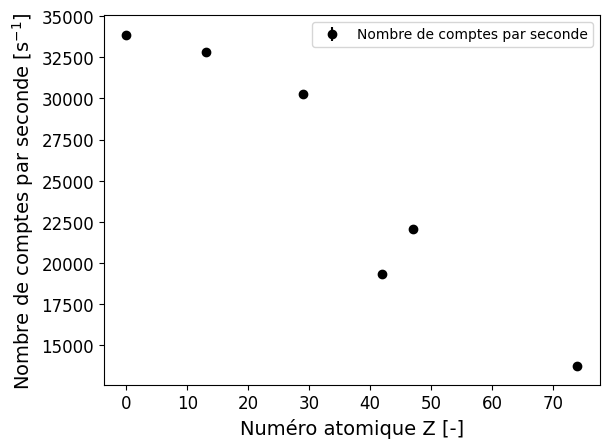

In [42]:
def find_energie_max(energies, counts, threshold=40):#3 pour tension, 8 pour courant
    # masque > seuil de bruit
    mask = counts > threshold
    # Indice du dernier point qui dépasse le seuil
    indices = np.where(mask)[0]

    idx_max = indices[-1]
    return energies[idx_max]

def droite(x, a, b):
    return (a*x)+b

def constante(x, k):
    return k*np.ones(len(x))

print(no_filter[128:])
print(len(no_filter[128:]))

filtres = np.array([no_filter[128:], Al_10mils[128:], Cu_1mils[128:], Mo_1mils[128:], Ag_1mils[128:], W_1mils[128:]])
t_acqu = np.array([60, 60, 60, 60, 60, 60])
#filtres_norm = filtres / t_acqu

energies_moy = []
i_energies_moy = []
energies_max = []
i_energies_moy = []
list_counts = []

energie = etalon(np.arange(128, 4096))
e_31 = energie[1300:1800]
#print(e_31)
#print(len(energie))
diff_energies = np.mean(np.diff(energie))

for filtre in filtres:
    energie_moy = np.average(energie, weights=filtre)
    energies_moy.append(energie_moy)

    i_energie_moy = np.sqrt(np.sum(filtre*(energie-energie_moy)**2)/((np.sum(filtre))**2))
    i_energies_moy.append(i_energie_moy)


    energie_max = find_energie_max(energie, filtre)
    energies_max.append(energie_max)

    sum_count = np.sum(filtre)
    list_counts.append(sum_count)

print(energies_moy)
    
print(list_counts)
Z = np.array([0, 13, 29, 42, 47, 74]) 
popt_moy, pcov_moy = curve_fit(droite, Z, energies_moy)
popt_max, pcov_max = curve_fit(constante, Z, energies_max)
x=np.linspace(0, 80, 1000)
plt.plot(x, droite(x, popt_moy[0], popt_moy[1]), color="blue", linestyle="-")
plt.plot(x, constante(x, popt_max[0]), color="red", linestyle="--")
i_moy = np.diag(pcov_moy)**0.5
i_max = np.diag(pcov_max)**0.5
print("\n", i_moy, popt_moy)
droite_min_moy = (popt_moy[0]-(2*i_moy[0]))*x + (popt_moy[1]-2*i_moy[1])
droite_max_moy = (popt_moy[0]+(2*i_moy[0]))*x + (popt_moy[1]+2*i_moy[1])
erreur_test = (diff_energies*np.ones(len(i_energies_moy)))


# Calcul de RMSE
def rmse(y, y_fit):
    return np.sqrt(np.mean((y - y_fit)**2))

y_fit_moy = droite(Z, popt_moy[0], popt_moy[1])
rmse_moy = rmse(energies_moy, y_fit_moy)

print("RMSE (énergies moyennes) =", rmse_moy, "keV")

y_fit_max = constante(Z, popt_max[0])
rmse_max = rmse(energies_max, y_fit_max)

print("RMSE (énergies maximales) =", rmse_max, "keV")


""" ss_res = np.sum((energies_moy - droite(Z, popt_moy[0], popt_moy[1]))**2)
ss_tot = np.sum((energies_moy - np.mean(energies_moy))**2)
r2_moy = 1 - ss_res/ss_tot

ss_res = np.sum((energies_max - droite(Z, popt_max[0], popt_max[1]))**2)
ss_tot = np.sum((energies_max - np.mean(energies_max))**2)
r2_max = 1 - ss_res/ss_tot """


plt.errorbar(Z, energies_moy, yerr=i_energies_moy, fmt='bs', ecolor = 'black', label = 'Énergies moyennes')
plt.fill_between(x, droite_min_moy, droite_max_moy, alpha=0.2, color="blue")
plt.errorbar(Z, energies_max, yerr=4*erreur_test, fmt='ro', ecolor = 'black', label = 'Énergies maximales')
plt.fill_between(x, popt_max[0]-3*(i_max[0]), popt_max[0]+3*(i_max[0]), alpha=0.2, color="red")
plt.legend()
plt.xlabel(r"Numéro atomique Z [-]", fontsize=14)
plt.text(40, 36, r"$E_{max}$"+ f" = ({popt_max[0]:.2f} ± {3*(pcov_max[0]**0.5)[0]:.2f}) keV\nRMSE = {rmse_max:.4f} keV", fontsize=12)#
plt.text(3, 28, r"$E_{moy}$"+ f' = {popt_moy[0]:.2f} Z +{popt_moy[1]:.2f}\nRMSE = {rmse_moy:.4f} keV', fontsize=12)#
plt.ylabel(r"Énergie [keV]", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12) 
#plt.grid()
plt.show()


# plt.plot(courants, energies_max, 'bo')
plt.errorbar(Z, list_counts/t_acqu, yerr=np.sqrt(list_counts/t_acqu), fmt='ko', ecolor = 'black', label = 'Nombre de comptes par seconde')
#plt.legend(loc=(0.42,0.40))
plt.legend(loc="upper right")
plt.xlabel(r"Numéro atomique Z [-]", fontsize=14)
plt.ylabel(r"Nombre de comptes par seconde [s$^{-1}$]", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12) 
#plt.grid()
plt.show()

# Section efficace

4984.383333333333
[4937.4        4664.53333333 2861.41666667 2034.2        2201.83333333]
[6.18750847e-24 3.08441894e-22 3.41316850e-21 6.01861650e-21
 5.08792351e-21]
[29.69243546 29.7103406  29.72824574 29.74615089 29.76405603 29.78196117
 29.79986631 29.81777145 29.8356766  29.85358174 29.87148688 29.88939202
 29.90729716 29.92520231 29.94310745 29.96101259 29.97891773 29.99682287
 30.01472802 30.03263316 30.0505383  30.06844344 30.08634858 30.10425373
 30.12215887 30.14006401 30.15796915 30.17587429 30.19377944 30.21168458
 30.22958972 30.24749486 30.2654     30.28330515 30.30121029 30.31911543
 30.33702057 30.35492571 30.37283086 30.390736   30.40864114 30.42654628
 30.44445142 30.46235657 30.48026171 30.49816685 30.51607199 30.53397713
 30.55188227 30.56978742 30.58769256 30.6055977  30.62350284 30.64140798
 30.65931313 30.67721827 30.69512341 30.71302855 30.73093369 30.74883884
 30.76674398 30.78464912 30.80255426 30.8204594  30.83836455 30.85626969
 30.87417483 30.89207997 30.9

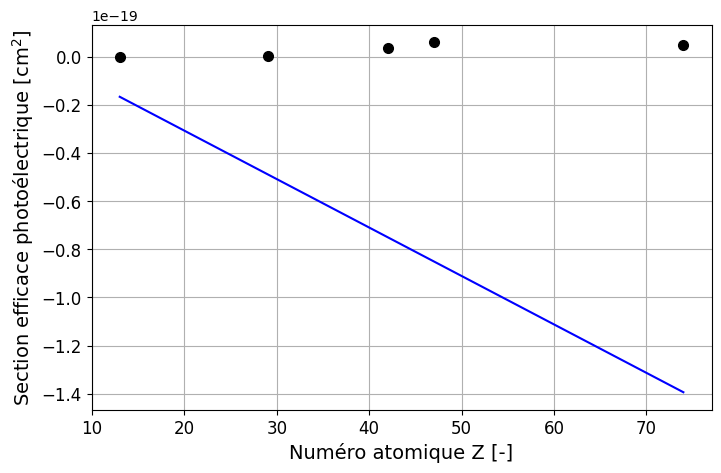

' # CALCUL R²\nFWHM_fit = fwhm_model2(E, a_fit, b_fit)\n#FWHM_fit = fwhm_model2(E, a_fit)\n\nss_res = np.sum((FWHM - FWHM_fit) ** 2)\nss_tot = np.sum((FWHM - np.mean(FWHM)) ** 2)\nR2_fwhm = 1 - ss_res / ss_tot\n\n\nRrel_fit = Rrel_model2(E, c_fit, d_fit)\n\nss_res = np.sum((R - Rrel_fit) ** 2)\nss_tot = np.sum((R - np.mean(R)) ** 2)\nR2_Rrel = 1 - ss_res / ss_tot\n\n\n#print(E)\n#print(E_err)\n\nprint(a_fit, b_fit)\nprint(c_fit, d_fit)\n\nprint(R2_fwhm)\nprint(R2_Rrel)\n'

In [43]:
NA = 6.022e23
mils = 25.4e-4

def sec_eff(N0, Nt, rho, t, A):
    return (-np.log(Nt/N0) * A) / (rho * t * NA) - 0.20 * (A / NA)


# NIST, NIH
A = np.array([26.9815385, 63.546, 95.95, 107.8682, 183.84])
rho = np.array([2.70, 8.933, 10.2, 10.501, 19.3])
t = np.array([10, 1, 1, 1, 1]) * mils


N0 = np.sum(no_filter[1550:1700]) / 60
Nt_Ag = np.sum(Ag_1mils[1550:1700]) / 60
Nt_Al = np.sum(Al_10mils[1550:1700]) / 60
Nt_Cu = np.sum(Cu_1mils[1550:1700]) / 60
Nt_Mo = np.sum(Mo_1mils[1550:1700]) / 60
Nt_W = np.sum(W_1mils[1550:1700]) / 60
Nt = np.array([Nt_Al, Nt_Cu, Nt_Mo, Nt_Ag, Nt_W])
print(N0)
print(Nt)
print((-np.log(Nt/N0))/(rho*t) * (A/NA))

print(energie[1550:1700])

sec_efficace= sec_eff(N0, Nt, rho, t, A)
Z = np.array([13, 29, 42, 47, 74])
     

def model(Z, c, n, b):
    return c * Z**n + b


def model2(Z, c):
    return c * Z**4

popt_model, _ = curve_fit(model, Z[:-1], sec_efficace[:-1])
c_fit, n_fit, b_fit = popt_model
print(sec_efficace[:-1])
print(c_fit, n_fit)


popt_model2, _ = curve_fit(model2, Z[:-1], sec_efficace[:-1])
c_fit2 = popt_model2


# =============================
# TRACE UNIQUE GRAPHIQUE
# =============================

fig, ax1 = plt.subplots(figsize=(8,5))
Z_fit = np.linspace(min(Z), max(Z), 300)


# FWHM
ax1.errorbar(Z, sec_efficace, fmt='o', ms=7, color="black", label="Données expérimentales")
ax1.plot(Z_fit, model(Z_fit, c_fit, n_fit, b_fit), color="blue", label=r"Fit: $R_{abs} = 2.45\sqrt{E}-10.10$"+"\n"+r"$\quad\quad R^2=0.99169$")
#ax1.plot(Z_fit, model2(Z_fit, c_fit), color="blue", label=r"Fit: $R_{abs} = 2.45\sqrt{E}-10.10$"+"\n"+r"$\quad\quad R^2=0.99169$")
ax1.set_xlabel("Numéro atomique Z [-]", size=14)
ax1.set_ylabel(r"Section efficace photoélectrique [cm$^2$]", size=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12) 
#ax1.legend(loc=(0.2,0.77))
#ax1.legend()
plt.grid()

plt.show()

#yerr=FWHM_err


""" # CALCUL R²
FWHM_fit = fwhm_model2(E, a_fit, b_fit)
#FWHM_fit = fwhm_model2(E, a_fit)

ss_res = np.sum((FWHM - FWHM_fit) ** 2)
ss_tot = np.sum((FWHM - np.mean(FWHM)) ** 2)
R2_fwhm = 1 - ss_res / ss_tot


Rrel_fit = Rrel_model2(E, c_fit, d_fit)

ss_res = np.sum((R - Rrel_fit) ** 2)
ss_tot = np.sum((R - np.mean(R)) ** 2)
R2_Rrel = 1 - ss_res / ss_tot


#print(E)
#print(E_err)

print(a_fit, b_fit)
print(c_fit, d_fit)

print(R2_fwhm)
print(R2_Rrel)
"""

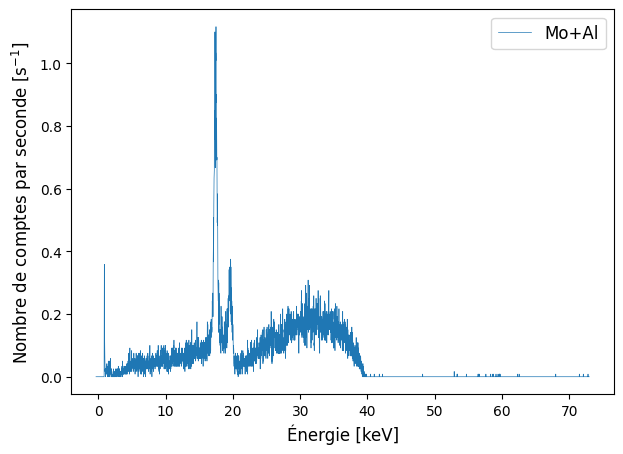

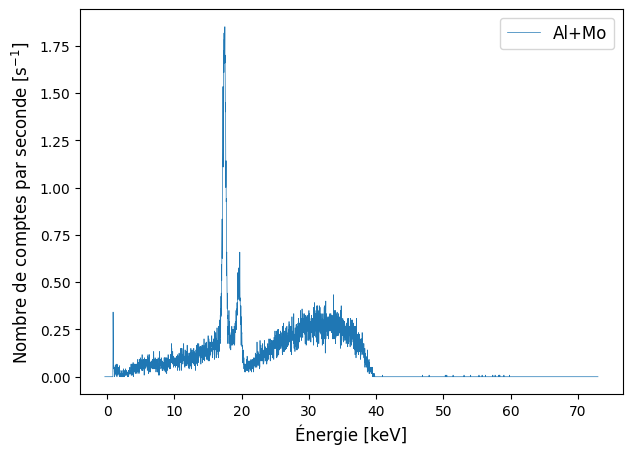

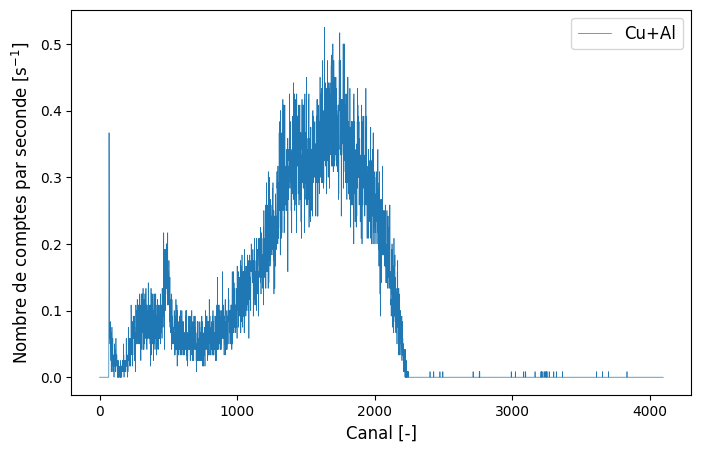

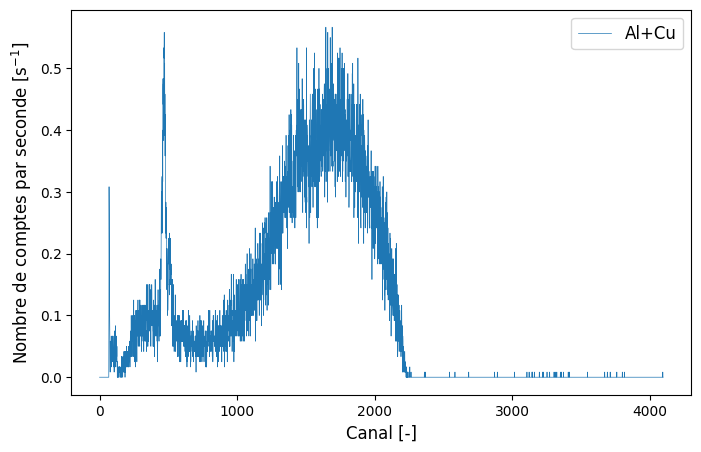

In [14]:
df = pd.read_csv(r'csv\Mo_Al.csv')
Mo_Al = df.to_numpy().ravel()

df = pd.read_csv(r'csv\Al_Mo.csv')
Al_Mo = df.to_numpy().ravel()


df = pd.read_csv(r'csv\Cu_Al.csv')
Cu_Al = df.to_numpy().ravel()

df = pd.read_csv(r'csv\Al_Cu.csv')
Al_Cu = df.to_numpy().ravel()


e = etalon(range(4096))
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(e, Mo_Al/120, lw=0.5, label=r"Mo+Al")
ax.legend(fontsize=12)
ax.set_xlabel("Énergie [keV]", size=12)
ax.set_ylabel("Nombre de comptes par seconde [s$^{-1}$]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(7,5))
ax.plot(e, Al_Mo/120, lw=0.5, label=r"Al+Mo")
ax.legend(fontsize=12)
ax.set_xlabel("Énergie [keV]", size=12)
ax.set_ylabel("Nombre de comptes par seconde [s$^{-1}$]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Cu_Al/120, lw=0.5, label=r"Cu+Al")
ax.legend(fontsize=12)
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes par seconde [s$^{-1}$]", size=12)
plt.show()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(range(4096), Al_Cu/120, lw=0.5, label=r"Al+Cu")
ax.legend(fontsize=12)
ax.set_xlabel("Canal [-]", size=12)
ax.set_ylabel("Nombre de comptes par seconde [s$^{-1}$]", size=12)
plt.show()



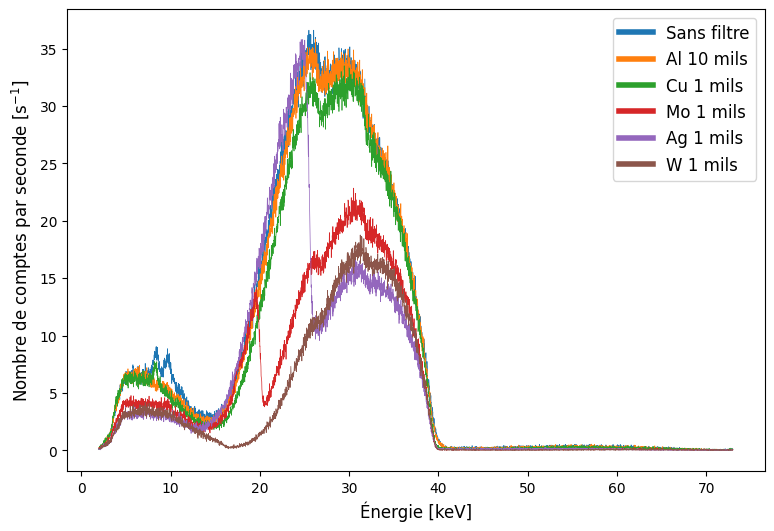

In [15]:
e = etalon(range(128, 4096))

fig, ax = plt.subplots(figsize=(9,6))
ax.plot(e, no_filter[128:]/60, lw=0.5, label=r"Sans filtre")
ax.plot(e, Al_10mils[128:]/60, lw=0.5, label=r"Al 10 mils")
ax.plot(e, Cu_1mils[128:]/60, lw=0.5, label=r"Cu 1 mils")
ax.plot(e, Mo_1mils[128:]/60, lw=0.5, label=r"Mo 1 mils")
ax.plot(e, Ag_1mils[128:]/60, lw=0.5, label=r"Ag 1 mils")
ax.plot(e, W_1mils[128:]/60, lw=0.5, label=r"W 1 mils")
legend = ax.legend(fontsize=12)

for line in legend.get_lines():
    line.set_linewidth(4) 
ax.set_xlabel("Énergie [keV]", size=12)
ax.set_ylabel(r"Nombre de comptes par seconde [s$^{-1}$]", size=12)
plt.show()

# Coefficient d'atténutation

In [ ]:
df = pd.read_csv(r'spectres_bruts\supp_csv\Al_10mils.csv')
Al_10mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Al_20mils.csv')
Al_20mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Al_30mils.csv')
Al_30mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Al_40mils.csv')
Al_40mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Al_50mils.csv')
Al_50mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Al_60mils.csv')
Al_60mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Al_70mils.csv')
Al_70mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Al_80mils.csv')
Al_80mils = df.to_numpy().ravel()



df = pd.read_csv(r'spectres_bruts\supp_csv\Cu_1mils.csv')
Cu_1mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Cu_2mils.csv')
Cu_2mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Cu_3mils.csv')
Cu_3mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Cu_4mils.csv')
Cu_4mils = df.to_numpy().ravel()

df = pd.read_csv(r'spectres_bruts\supp_csv\Cu_5mils.csv')
Cu_5mils = df.to_numpy().ravel()

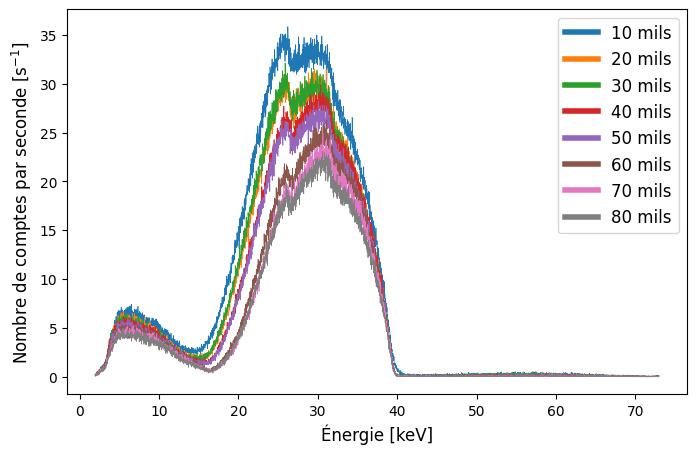

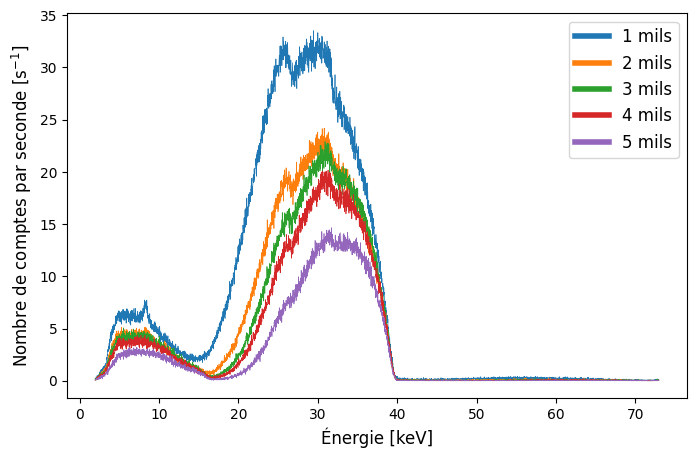

In [26]:

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(e, Al_10mils[128:]/60, lw=0.5, label=r"10 mils")
ax.plot(e, Al_20mils[128:]/60, lw=0.5, label=r"20 mils")
ax.plot(e, Al_30mils[128:]/60, lw=0.5, label=r"30 mils")
ax.plot(e, Al_40mils[128:]/60, lw=0.5, label=r"40 mils")
ax.plot(e, Al_50mils[128:]/60, lw=0.5, label=r"50 mils")
ax.plot(e, Al_60mils[128:]/60, lw=0.5, label=r"60 mils")
ax.plot(e, Al_70mils[128:]/60, lw=0.5, label=r"70 mils")
ax.plot(e, Al_80mils[128:]/60, lw=0.5, label=r"80 mils")
legend = ax.legend(fontsize=12)

for line in legend.get_lines():
    line.set_linewidth(4) 
ax.set_xlabel("Énergie [keV]", size=12)
ax.set_ylabel(r"Nombre de comptes par seconde [s$^{-1}$]", size=12)
plt.show()


fig, ax = plt.subplots(figsize=(8,5))
ax.plot(e, Cu_1mils[128:]/60, lw=0.5, label=r"1 mils")
ax.plot(e, Cu_2mils[128:]/60, lw=0.5, label=r"2 mils")
ax.plot(e, Cu_3mils[128:]/60, lw=0.5, label=r"3 mils")
ax.plot(e, Cu_4mils[128:]/60, lw=0.5, label=r"4 mils")
ax.plot(e, Cu_5mils[128:]/60, lw=0.5, label=r"5 mils")
legend = ax.legend(fontsize=12)

for line in legend.get_lines():
    line.set_linewidth(4) 
ax.set_xlabel("Énergie [keV]", size=12)
ax.set_ylabel(r"Nombre de comptes par seconde [s$^{-1}$]", size=12)
plt.show()

0.17905141963904725
41.23229945637631 3.3772865884019896
22.252848974637295 78.75407210311712


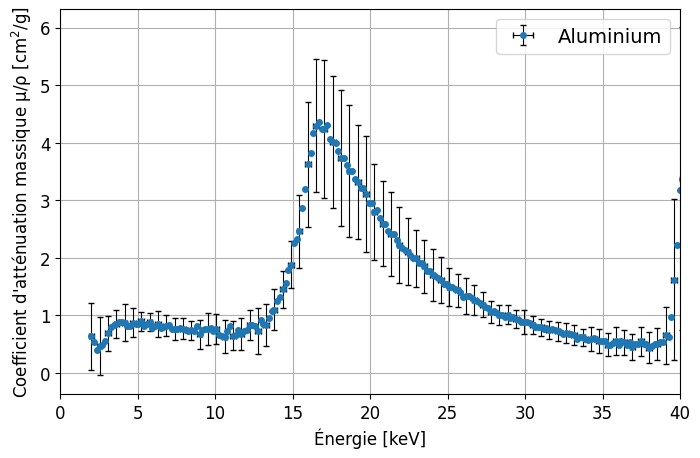

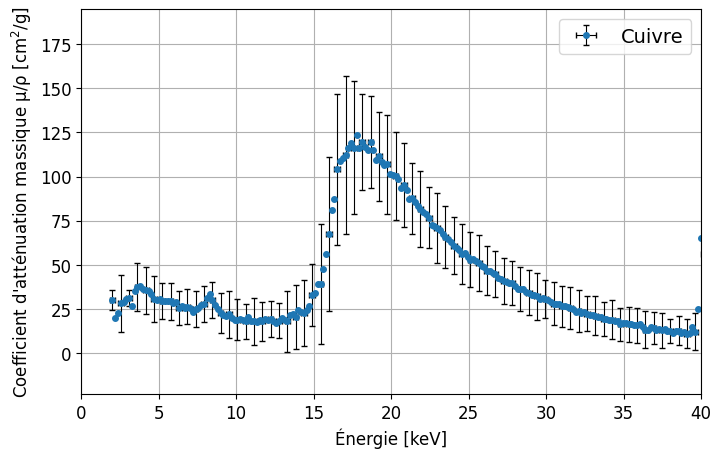

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# -----------------------------
# Modèle exponentiel
# -----------------------------
def modele_log(x, lnN0, mu):
    return lnN0 - mu * x

def expo(t, N0, mu):
    return N0 * np.exp(-mu * t)

# -----------------------------
# Données à fournir
# -----------------------------

# épaisseurs en cm 
t_Al = np.array([10, 20, 30, 40, 50, 60, 70, 80]) * mils 
t_Cu = np.array([1, 2, 3, 4, 5]) * mils 

# spectres : liste ou array 2D
# shape = (nombre d'épaisseurs, nombre de canaux)
# spectra[i, j] = counts pour épaisseur i au canal j
spectres_Al = np.array([Al_10mils[128:], Al_20mils[128:], Al_30mils[128:], Al_40mils[128:], Al_50mils[128:], Al_60mils[128:], Al_70mils[128:], Al_80mils[128:]])
spectres_Al = spectres_Al / 60
spectres_Cu = np.array([Cu_1mils[128:], Cu_2mils[128:], Cu_3mils[128:], Cu_4mils[128:], Cu_5mils[128:]])
spectres_Cu = spectres_Cu / 60



def bin_spectra(spectra, bin_size):
    """
    Regroupe les canaux par paquets de taille bin_size
    spectra: array (n_epaisseurs, n_canaux)
    """
    n_bins = spectra.shape[1] // bin_size
    
    binned = np.zeros((spectra.shape[0], n_bins))
    
    for i in range(n_bins):
        start = i * bin_size
        end = start + bin_size
        binned[:, i] = np.sum(spectra[:, start:end], axis=1)
    
    return binned


# nombre de canaux
n_canaux = spectres_Al.shape[1]

bin_size = 10  # à ajuster
spectres_Al_bin = bin_spectra(spectres_Al, bin_size)
spectres_Cu_bin = bin_spectra(spectres_Cu, bin_size)
no_filter_bin = bin_spectra(no_filter.reshape(1, -1), bin_size)
no_filter_bin = no_filter_bin.ravel()


n_canaux_bin = spectres_Al_bin.shape[1]

# tableau pour stocker mu(E) et incertitude
mu_valeur_Al, mu_valeur_Cu = np.zeros(n_canaux_bin), np.zeros(n_canaux_bin)
sigma_mu_Al, sigma_mu_Cu = np.zeros(n_canaux_bin), np.zeros(n_canaux_bin)

#mu_valeur_Al, mu_valeur_Cu = np.zeros(n_canaux), np.zeros(n_canaux)
#sigma_mu_Al, sigma_mu_Cu = np.zeros(n_canaux), np.zeros(n_canaux)

# -----------------------------
# Fit pour chaque canal
# -----------------------------
for ch in range(n_canaux_bin):
    counts = spectres_Al_bin[:, ch]
    

    popt, _ = curve_fit(expo, t_Al, counts, p0=(counts[0], 1.0))
    mu_valeur_Al[ch] = popt[1]
    if np.all(counts > 0):
        Nt = np.log(counts)
        p, cov = np.polyfit(t_Al, Nt, 1, cov=True)
        sigma_mu = np.sqrt(cov[0, 0])

        mu_valeur_Al[ch] = -p[0]
        sigma_mu_Al[ch] = sigma_mu

    else:
        mu_valeur_Al[ch] = np.nan
        sigma_mu_Al[ch] = np.nan

for ch in range(n_canaux_bin):
    counts = spectres_Cu_bin[:, ch]
    
    if np.all(counts > 0):
        Nt = np.log(counts)
        p, cov = np.polyfit(t_Cu, Nt, 1, cov=True)
        sigma_mu = np.sqrt(cov[0, 0])

        mu_valeur_Cu[ch] = -p[0]
        sigma_mu_Cu[ch] = sigma_mu

    else:
        mu_valeur_Cu[ch] = np.nan
        sigma_mu_Cu[ch] = np.nan


""" for ch in range(n_canaux):
    counts = spectres_Al[:, ch]
    
    if np.all(counts > 0):
        Nt = np.log(counts)
        p, cov = np.polyfit(t_Al, Nt, 1, cov=True)
        sigma_mu = np.sqrt(cov[0, 0])

        mu_valeur_Al[ch] = -p[0]
        sigma_mu_Al[ch] = sigma_mu

    else:
        mu_valeur_Al[ch] = np.nan
        sigma_mu_Al[ch] = np.nan

for ch in range(n_canaux):
    counts = spectres_Cu[:, ch]
    
    if np.all(counts > 0):
        Nt = np.log(counts)
        p, cov = np.polyfit(t_Cu, Nt, 1, cov=True)
        sigma_mu = np.sqrt(cov[0, 0])

        mu_valeur_Cu[ch] = -p[0]
        sigma_mu_Cu[ch] = sigma_mu

    else:
        mu_valeur_Cu[ch] = np.nan
        sigma_mu_Cu[ch] = np.nan """




# -----------------------------
# Axe énergie (à adapter)
# -----------------------------
# si calibration : E = a * canal + b


def bin_array(arr, bin_size):
    n_bins = len(arr) // bin_size
    arr = arr[:n_bins * bin_size]
    return arr.reshape(n_bins, bin_size).mean(axis=1)

energie_binned = bin_array(e, bin_size)
err_energie = bin_size * a
print(err_energie)


print(energie_binned[219], (mu_valeur_Al/rho[0])[219] )
print(energie_binned[113], (mu_valeur_Cu/rho[0])[113] )
# -----------------------------
# Plot μ(E)
# -----------------------------
plt.figure(figsize=(8,5))
plt.errorbar(energie_binned, mu_valeur_Al/rho[0], xerr=err_energie, yerr=sigma_mu_Al, fmt='o', ecolor = 'black', markersize=4, capsize=2.5, elinewidth=0.8, errorevery=3, label="Aluminium")
#plt.errorbar(e, mu_valeur_Al/rho[0], yerr=sigma_mu_Al, fmt='o', ecolor = 'black', markersize=4, capsize=2.5, elinewidth=0.8, errorevery=3, label="Aluminium")
#plt.fill_between(energie_binned, mu_valeur_Al/rho[0] - sigma_mu_Al, mu_valeur_Al/rho[0] + sigma_mu_Al, alpha=0.3)
plt.xlabel("Énergie [keV]", fontsize=12)
plt.ylabel("Coefficient d'atténuation massique μ/ρ [cm$^2$/g]", fontsize=12)
plt.xlim(0, 40)
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12) 
#plt.yscale("log")
plt.grid()
plt.show()


plt.figure(figsize=(8,5))
plt.errorbar(energie_binned, mu_valeur_Cu/rho[0], xerr=err_energie, yerr=sigma_mu_Cu, fmt='o', ecolor = 'black', markersize=4, capsize=2.5, elinewidth=0.8, errorevery=3, label="Cuivre")
#plt.errorbar(e, mu_valeur_Cu/rho[0], yerr=sigma_mu_Cu, fmt='o', ecolor = 'black', markersize=4, capsize=2.5, elinewidth=0.8, errorevery=3, label="Cuivre")
plt.xlabel("Énergie [keV]", fontsize=12)
plt.ylabel("Coefficient d'atténuation massique μ/ρ [cm$^2$/g]", fontsize=12)
plt.xlim(0, 40)
#plt.xscale("log")
#plt.yscale("log")
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12) 
plt.grid()
plt.show()


[27.26628872 27.44534014 27.62439156 27.80344298 27.9824944  28.16154582
 28.34059724 28.51964866 28.69870008 28.8777515  29.05680292 29.23585434
 29.41490576 29.59395718 29.7730086  29.95206002 30.13111144 30.31016286
 30.48921428 30.6682657  30.84731712 31.02636854 31.20541996 31.38447138
 31.5635228  31.74257422 31.92162564 32.10067705 32.27972847 32.45877989
 32.63783131 32.81688273 32.99593415 33.17498557 33.35403699 33.53308841
 33.71213983 33.89119125 34.07024267 34.24929409 34.42834551 34.60739693
 34.78644835 34.96549977 35.14455119 35.32360261 35.50265403 35.68170545
 35.86075687]
[1, 0.9046968799933792, 0.8016812767772449, 0.7973841854306322, 0.7656854444253463, 0.7271028691838072, 0.6762327347113734, 0.6329222979783512, 0.5984373441641254]


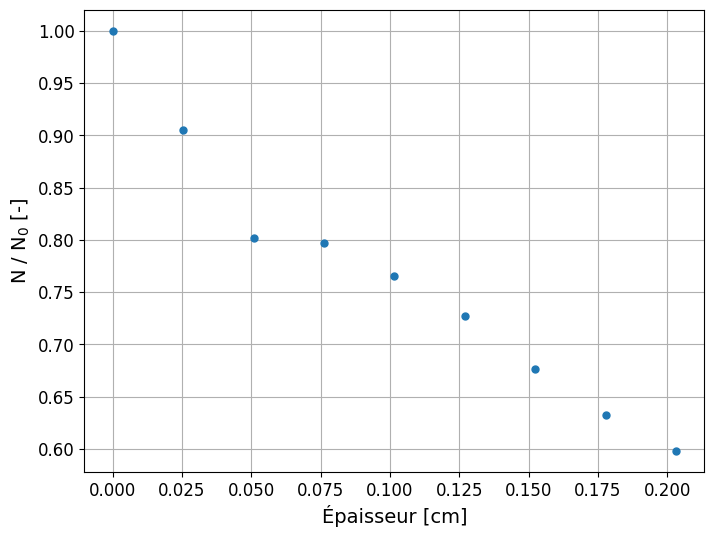

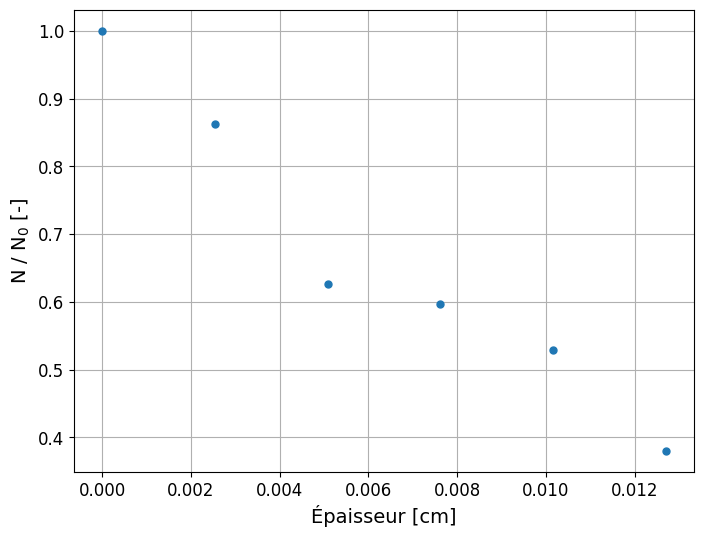

In [52]:
ep_Al = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80]) * mils 
ep_Cu = np.array([0, 1, 2, 3, 4, 5]) * mils 



def find_x(target, t, N_norm):
    for i in range(len(t)-1):
        if N_norm[i] >= target >= N_norm[i+1]:
            # interpolation linéaire
            return t[i] + (target - N_norm[i]) * (t[i+1] - t[i]) / (N_norm[i+1] - N_norm[i]), (t[i+1]-t[i])/2


# Trouver CDA
N_norm_Al = [1]
print(energie_binned[141:190])
for spectre in spectres_Al_bin:
    spectre_31 = np.sum(spectre[141:190])
    #print(spectre[161:190])
    #print(spectre_31)
    no_filter_31 = np.sum(no_filter_bin[141:190]/60)
    N_norm_Al.append(spectre_31/no_filter_31)
print(N_norm_Al)

N_norm_Cu = [1]
for spectre in spectres_Cu_bin:
    spectre_31 = np.sum(spectre[141:190])
    #print(spectre[161:190])
    #print(spectre_31)
    no_filter_31 = np.sum(no_filter_bin[141:190]/60)
    N_norm_Cu.append(spectre_31/no_filter_31)




""" cda1_Al, inc_cda1_Al = find_x(0.5, ep_Al, N_norm_Al)
x_total, _ = find_x(0.25, ep_Al, N_norm_Al)
cda2_Al = x_total - cda1_Al

cda1_Cu, inc_cda1_Cu = find_x(0.5, ep_Cu, N_norm_Cu)
x_total, _ = find_x(0.25, ep_Cu, N_norm_Cu)
cda2_Cu = x_total - cda1_Cu


print("Première CDA =", cda1_Al )
print("Deuxième CDA =", cda2_Al)

print("Première CDA =", cda1_Cu )
print("Deuxième CDA =", cda2_Cu) """

plt.figure(figsize=(8,6))
h1 = plt.errorbar(ep_Al, N_norm_Al, fmt='o', ecolor = 'black', markersize=5, label=f"Données expérimentales (Al)")
#h2 = plt.plot([], [], ' ', label=f"CDA1 = ({cda1_Al:.4f} ± {inc_cda1_Al:.4f}) cm\nCDA2 = ({cda2_Al:.4f} ± {inc_cda1_Al:.4f}) cm")[0]
#plt.plot(energie_binned, mu_valeur_Al/rho[0], 'o', markersize=4)
#plt.fill_between(energie_binned, mu_valeur_Al/rho[0] - sigma_mu_Al, mu_valeur_Al/rho[0] + sigma_mu_Al, alpha=0.3)
plt.xlabel("Épaisseur [cm]", fontsize=14)
plt.ylabel("N / N$_0$ [-]", fontsize=14)
#plt.xlim(0, 40)
#plt.legend(fontsize=14, handles=[h1, h2])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12) 
#plt.yscale("log")
plt.grid()
plt.show()

plt.figure(figsize=(8,6))
h1 = plt.errorbar(ep_Cu, N_norm_Cu, fmt='o', ecolor = 'black', markersize=5, label=f"Données expérimentales (Cu)")
#h2 = plt.plot([], [], ' ', label=f"CDA1 = ({cda1_Cu:.4f} ± {inc_cda1_Cu:.4f}) cm\nCDA2 = ({cda2_Cu:.4f} ± {inc_cda1_Cu:.4f}) cm")[0]
#plt.plot(energie_binned, mu_valeur_Al/rho[0], 'o', markersize=4)
#plt.fill_between(energie_binned, mu_valeur_Al/rho[0] - sigma_mu_Al, mu_valeur_Al/rho[0] + sigma_mu_Al, alpha=0.3)
plt.xlabel("Épaisseur [cm]", fontsize=14)
plt.ylabel("N / N$_0$ [-]", fontsize=14)
#plt.xlim(0, 40)
#plt.legend(fontsize=14, handles=[h1, h2])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12) 
#plt.yscale("log")
plt.grid()
plt.show()